# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [34]:
ПІБ = 'Гуменюк Анастасія Олександрівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 5     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [35]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Гуменюк Анастасія Олександрівна, ШІ-31, варіант 5
ваш потік:                   P>1
ваша пара для графіка 3:     радіопотік F10.7 та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [37]:
# ВАШ КОД
df = pd.read_excel(ФАЙЛ, sheet_name='Sheet1')

display(df.head())
print(df.dtypes)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

Звичайне читання дало такий результат, тому що на початку аркуша знаходиться службова інформація, а не готова таблиця. Pandas автоматично взяв перший рядок за назви стовпців, тому з’явилися стовпці Unnamed. Порожні клітинки відображаються як NaN, а стовпці з текстом або різними видами даних отримали тип object. Отже, перед аналізом потрібно знайти справжній заголовок таблиці та очистити дані.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [38]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, sheet_name='Sheet1', header=None)

print("Розмір таблиці:", RAW.shape)
display(RAW.head(30))


Розмір таблиці: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [39]:
# ВАШ КОД
filled_cells = RAW.notna().sum()
print(filled_cells)

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

Дійсно, є 32 стовпці (0-31). За кількістю заповнених клітинок видно, що на аркуші розміщено три окремі таблиці. Перша таблиця займає стовпці 1-14, друга - 16-19, а третя - 24-31. Стовпці 0, 15 і 20–23 порожні та розділяють ці таблиці.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [40]:
# ВАШ КОД
display(RAW.iloc[:26, 1:15].dropna(how='all'))

display(RAW.iloc[:26, 16:20].dropna(how='all'))

display(RAW.iloc[:26, 24:32].dropna(how='all'))

,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,# Label: P >30 = Particles at >30 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,16,17,18,19
13,ftp://ftp.swpc.noaa.gov/pub/indices/old_indice...,NaN,NaN,NaN
15,Product: Daily Solar Data quar_DSD.txt,NaN,NaN,NaN
16,:Issued: 0825 UT 04 Oct 2017,NaN,NaN,NaN
17,#,NaN,NaN,NaN
18,"# Prepared by the U.S. Dept. of Commerce, NOA...",NaN,NaN,NaN
19,# Please send comments and suggestions to SWP...,NaN,NaN,NaN
23,Quarterly Daily Solar Data,NaN,NaN,NaN


,24,25,26,27,28,29,30,31
0,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | GOES-15 NOAA Space Weather Prediction Center | протони - Protons/cm2-s-sr електорни - Electrons cm2-s-sr енергія MeV |
| B | NOAA Space Weather Prediction Center | сонячна активність Radio Flux 10.7 |
| C |  SOHO CELIAS Proton Monitor | швидкість протона - [km/sec] густина - protons per cubic centimeter|


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [41]:
# ВАШ КОД
A = RAW.iloc[26:, 1:15].dropna(how="all").copy()

A.columns = [
    "year", "month", "day", "time_hhmm",
    "julian_day", "seconds_of_day",
    "proton_gt_1_MeV", "proton_gt_5_MeV",
    "proton_gt_10_MeV", "proton_gt_30_MeV",
    "proton_gt_50_MeV", "proton_gt_100_MeV",
    "electron_gt_0_8_MeV", "electron_gt_2_MeV"
]


B = RAW.iloc[27:, 16:20].dropna(how="all").copy()

B.columns = [
    "year", "month", "day", "radio_flux_10_7"
]


C = RAW.iloc[27:, 24:32].dropna(how="all").copy()

C.columns = [
    "hour_index_1", "hour_index_2",
    "year", "month", "day", "hour",
    "proton_speed_km_s", "proton_density_cm3"
]


A = A.apply(pd.to_numeric, errors="coerce").reset_index(drop=True) #якщо значення неможливо перетворити на число, заміни його на NaN
B = B.apply(pd.to_numeric, errors="coerce").reset_index(drop=True)
C = C.apply(pd.to_numeric, errors="coerce").reset_index(drop=True)


print("Розмір A:", A.shape)
display(A.head())

print("Розмір B:", B.shape)
display(B.head())

print("Розмір C:", C.shape)
display(C.head())

Розмір A: (7200, 14)


,year,month,day,time_hhmm,julian_day,seconds_of_day,proton_gt_1_MeV,proton_gt_5_MeV,proton_gt_10_MeV,proton_gt_30_MeV,proton_gt_50_MeV,proton_gt_100_MeV,electron_gt_0_8_MeV,electron_gt_2_MeV
0,2017,8,28,0,57993,0,12.00,0.260,0.180,0.1140,0.1040,0.0793,23600.0,1180.0
1,2017,8,28,5,57993,300,19.40,0.690,0.314,0.1120,0.0612,0.0251,23100.0,1160.0
2,2017,8,28,10,57993,600,8.48,0.168,0.130,0.0717,0.0614,0.0304,22200.0,1090.0
3,2017,8,28,15,57993,900,15.40,0.566,0.198,0.0926,0.0568,0.0251,20400.0,997.0
4,2017,8,28,20,57993,1200,6.41,0.156,0.118,0.0597,0.0494,0.0251,18500.0,875.0


Розмір B: (25, 4)


,year,month,day,radio_flux_10_7
0,2017,8,28,82
1,2017,8,29,84
2,2017,8,30,87
3,2017,8,31,92
4,2017,9,1,93


Розмір C: (601, 8)


,hour_index_1,hour_index_2,year,month,day,hour,proton_speed_km_s,proton_density_cm3
0,0.0,0.0,17,8,28,0,285,3.0
1,1.0,1.0,17,8,28,1,305,3.4
2,2.0,2.0,17,8,28,2,309,1.7
3,3.0,3.0,17,8,28,3,304,2.0
4,4.0,4.0,17,8,28,4,302,2.3


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [42]:
# ВАШ КОД
A["ts"] = pd.to_datetime({
    "year": A["year"],
    "month": A["month"],
    "day": A["day"],
    "hour": A["time_hhmm"] // 100,
    "minute": A["time_hhmm"] % 100
})

B["ts"] = pd.to_datetime({
    "year": B["year"],
    "month": B["month"],
    "day": B["day"]
})

C["ts"] = pd.to_datetime({
    "year": C["year"] + 2000,
    "month": C["month"],
    "day": C["day"],
    "hour": C["hour"]
})

for name, table in {"A": A, "B": B, "C": C}.items():
    print(f"Таблиця {name}")
    print("Тип ts:", table["ts"].dtype)
    print("Найраніша дата:", table["ts"].min())
    print("Найпізніша дата:", table["ts"].max())
    print()

Таблиця A
Тип ts: datetime64[ns]
Найраніша дата: 2017-08-28 00:00:00
Найпізніша дата: 2017-09-21 23:55:00

Таблиця B
Тип ts: datetime64[ns]
Найраніша дата: 2017-08-28 00:00:00
Найпізніша дата: 2017-09-21 00:00:00

Таблиця C
Тип ts: datetime64[ns]
Найраніша дата: 2017-08-28 00:00:00
Найпізніша дата: 2017-09-22 00:00:00



**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [43]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [44]:
# ВАШ КОД
tables = {
    "A": A,
    "B": B,
    "C": C
}

for name, table in tables.items():
    print(f"\n===== Таблиця {name} =====")

    print("Розмір:")
    print(table.shape)

    print("\nТипи стовпців:")
    print(table.dtypes)

    print("\nКількість пропусків:")
    print(table.isna().sum())

    print("\nКількість повних дублікатів:")
    print(table.duplicated().sum())

    print("\nОписові статистики:")
    display(table.describe())


===== Таблиця A =====
Розмір:
(7200, 15)

Типи стовпців:
year                            int64
month                           int64
day                             int64
time_hhmm                       int64
julian_day                      int64
seconds_of_day                  int64
proton_gt_1_MeV               float64
proton_gt_5_MeV               float64
proton_gt_10_MeV              float64
proton_gt_30_MeV              float64
proton_gt_50_MeV              float64
proton_gt_100_MeV             float64
electron_gt_0_8_MeV           float64
electron_gt_2_MeV             float64
ts                     datetime64[ns]
dtype: object

Кількість пропусків:
year                   0
month                  0
day                    0
time_hhmm              0
julian_day             0
seconds_of_day         0
proton_gt_1_MeV        3
proton_gt_5_MeV        3
proton_gt_10_MeV       3
proton_gt_30_MeV       3
proton_gt_50_MeV       3
proton_gt_100_MeV      3
electron_gt_0_8_MeV    3
electron_gt

,year,month,day,time_hhmm,julian_day,seconds_of_day,proton_gt_1_MeV,proton_gt_5_MeV,proton_gt_10_MeV,proton_gt_30_MeV,proton_gt_50_MeV,proton_gt_100_MeV,electron_gt_0_8_MeV,electron_gt_2_MeV,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN



===== Таблиця B =====
Розмір:
(25, 5)

Типи стовпців:
year                        int64
month                       int64
day                         int64
radio_flux_10_7             int64
ts                 datetime64[ns]
dtype: object

Кількість пропусків:
year               0
month              0
day                0
radio_flux_10_7    0
ts                 0
dtype: int64

Кількість повних дублікатів:
0

Описові статистики:


,year,month,day,radio_flux_10_7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN



===== Таблиця C =====
Розмір:
(601, 9)

Типи стовпців:
hour_index_1                 float64
hour_index_2                 float64
year                           int64
month                          int64
day                            int64
hour                           int64
proton_speed_km_s              int64
proton_density_cm3           float64
ts                    datetime64[ns]
dtype: object

Кількість пропусків:
hour_index_1          0
hour_index_2          0
year                  0
month                 0
day                   0
hour                  0
proton_speed_km_s     0
proton_density_cm3    0
ts                    0
dtype: int64

Кількість повних дублікатів:
0

Описові статистики:


,hour_index_1,hour_index_2,year,month,day,hour,proton_speed_km_s,proton_density_cm3,ts
count,601.000000,601.000000,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,11.480865,11.480865,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,0.000000,0.000000,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,5.000000,5.000000,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,11.000000,11.000000,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.000000,17.000000,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,23.000000,23.000000,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,6.938063,6.938063,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [45]:
# ВАШ КОД
cols = ["proton_speed_km_s", "proton_density_cm3"]

negative_counts = (C[cols] < 0).sum()

before = C[cols].agg(["mean", "min"])

C[cols] = C[cols].mask(C[cols] < 0, np.nan)

after = C[cols].agg(["mean", "min"])

result = pd.DataFrame({
    "від’ємних значень": negative_counts,
    "середнє до": before.loc["mean"],
    "середнє після": after.loc["mean"],
    "мінімум до": before.loc["min"],
    "мінімум після": after.loc["min"]
})

display(result.round(3))

,від’ємних значень,середнє до,середнє після,мінімум до,мінімум після
proton_speed_km_s,8,506.547,513.395,-1.0,277.0
proton_density_cm3,8,2.908,2.960,-1.0,0.1


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

В обох стовпцях я знайшла по 8 від’ємних значень. Усі вони дорівнювали -1, що у службовому описі означає відсутнє вимірювання. Після заміни цих значень на NaN мінімальна швидкість змінилася з -1 до 277 км/с, а мінімальна густина - з -1 до 0,1 протона/см³. Середні значення трохи збільшилися, оскільки NaN не враховується під час обчислення середнього.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [46]:
# ВАШ КОД
date_time_cols = [
    "year",
    "month",
    "day",
    "time_hhmm",
    "julian_day",
    "seconds_of_day"
]

result = A[date_time_cols].agg(["mean", "std"])

display(result.round(2))

,year,month,day,time_hhmm,julian_day,seconds_of_day
mean,2017.0,8.84,13.96,1177.50,58005.00,43050.00
std,0.0,0.37,8.78,692.48,7.21,24943.11


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

На мою думку, середнє не має нормального змісту для стовпців year, month, day, time_hhmm, julian_day і seconds_of_day. Ці числа є частинами дати та часу, а не результатами фізичних вимірювань. Наприклад, середній місяць 8,84 або середній день 13,96 не є справжньою календарною датою. Середнє значення року також нічого не пояснює, оскільки всі спостереження зроблені у 2017 році.
Особливо безглуздим є середнє для time_hhmm, тому що час записаний як звичайне число у форматі HHMM. Наприклад, середнє між 10:50 і 11:10, якщо рахувати числа 1050 і 1110, дорівнюватиме 1080, але часу 10:80 не існує. Для роботи з датою і часом правильніше використовувати створений стовпець ts.
Натомість середнє має фізичний зміст для стовпців із потоками протонів та електронів, оскільки вони містять результати вимірювань.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [47]:
# ВАШ КОД
flux_cols = [
    "proton_gt_1_MeV",
    "proton_gt_5_MeV",
    "proton_gt_10_MeV",
    "proton_gt_30_MeV",
    "proton_gt_50_MeV",
    "proton_gt_100_MeV",
    "electron_gt_0_8_MeV",
    "electron_gt_2_MeV"
]

A_hourly = (
    A.set_index("ts")[flux_cols]
     .resample("1h")
     .agg(["mean", "max"])
)

A_hourly.columns = [
    f"{column}_{statistic}"
    for column, statistic in A_hourly.columns
]

A_hourly = A_hourly.reset_index()

print("Розмір погодинної таблиці:", A_hourly.shape)
display(A_hourly.head())

Розмір погодинної таблиці: (600, 17)


,ts,proton_gt_1_MeV_mean,proton_gt_1_MeV_max,proton_gt_5_MeV_mean,proton_gt_5_MeV_max,proton_gt_10_MeV_mean,proton_gt_10_MeV_max,proton_gt_30_MeV_mean,proton_gt_30_MeV_max,proton_gt_50_MeV_mean,proton_gt_50_MeV_max,proton_gt_100_MeV_mean,proton_gt_100_MeV_max,electron_gt_0_8_MeV_mean,electron_gt_0_8_MeV_max,electron_gt_2_MeV_mean,electron_gt_2_MeV_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

,median,max
ts,,
2017-09-08 00:00:00,5135.0,8360.0
2017-09-08 01:00:00,4880.0,9380.0
2017-09-08 02:00:00,2695.0,3120.0
2017-09-08 03:00:00,2600.0,3330.0
2017-09-08 04:00:00,3210.0,4230.0
2017-09-08 05:00:00,4200.0,4540.0
2017-09-08 06:00:00,2160.0,2590.0
2017-09-08 07:00:00,2385.0,2560.0
2017-09-08 08:00:00,2870.0,3210.0


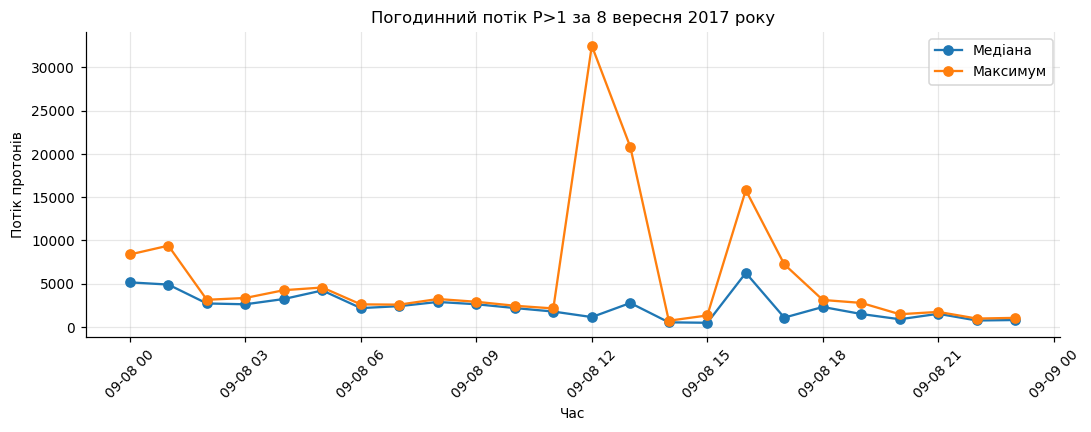

In [48]:
# ВАШ КОД
flow = "proton_gt_1_MeV"
selected_day = "2017-09-08"

day_data = (
    A.set_index("ts")
     .loc[selected_day, flow]
)

hourly_comparison = day_data.resample("1h").agg(["median", "max"])

display(hourly_comparison)

plt.figure(figsize=(10, 4))

plt.plot(
    hourly_comparison.index,
    hourly_comparison["median"],
    marker="o",
    label="Медіана"
)

plt.plot(
    hourly_comparison.index,
    hourly_comparison["max"],
    marker="o",
    label="Максимум"
)

plt.title("Погодинний потік P>1 за 8 вересня 2017 року")
plt.xlabel("Час")
plt.ylabel("Потік протонів")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

На графіку видно, що медіана змінюється більш плавно, оскільки вона показує центральне значення за годину та майже не реагує на короткі сплески. Максимум, навпаки, різко зростає, якщо протягом години було хоча б одне дуже велике значення. Найбільша різниця спостерігається о 12:00: медіана становить приблизно 1120, а максимум - 32500. Отже, у цей час стався короткочасний сильний сплеск потоку протонів, але високий рівень не зберігався протягом усієї години.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [49]:
# ВАШ КОД
M = None

C_hourly = C[
    ["ts", "proton_speed_km_s", "proton_density_cm3"]
].copy()

hourly_grid = pd.date_range(
    start=B["ts"].min(),
    end=B["ts"].max() + pd.Timedelta(hours=23),
    freq="1h"
)

B_hourly = (
    B.set_index("ts")[["radio_flux_10_7"]]
     .reindex(hourly_grid)#ставить nan в години які не мають значень в сітці
     .ffill() #заповнює пропуски останнім відомим значенням
     .rename_axis("ts")
     .reset_index()
)

print("A_hourly:", A_hourly.shape)
print("B_hourly:", B_hourly.shape)
print("C_hourly:", C_hourly.shape)

# Лише години, які є в усіх трьох таблицях
M_inner = (
    A_hourly
    .merge(C_hourly, on="ts", how="inner")
    .merge(B_hourly, on="ts", how="inner")
)

# Усі години, які є хоча б в одній таблиці
M_outer = (
    A_hourly
    .merge(C_hourly, on="ts", how="outer")
    .merge(B_hourly, on="ts", how="outer")
    .sort_values("ts")
    .reset_index(drop=True)
)

print("Розмір inner:", M_inner.shape)
print("Розмір outer:", M_outer.shape)

M = M_inner.copy()

print("Розмір M:", M.shape)

missing_rows = M[M.isna().any(axis=1)]

print("Рядків хоча б з одним пропуском:", len(missing_rows))
display(missing_rows)

A_hourly: (600, 17)
B_hourly: (600, 2)
C_hourly: (601, 3)
Розмір inner: (600, 20)
Розмір outer: (601, 20)
Розмір M: (600, 20)
Рядків хоча б з одним пропуском: 8


,ts,proton_gt_1_MeV_mean,proton_gt_1_MeV_max,proton_gt_5_MeV_mean,proton_gt_5_MeV_max,proton_gt_10_MeV_mean,proton_gt_10_MeV_max,proton_gt_30_MeV_mean,proton_gt_30_MeV_max,proton_gt_50_MeV_mean,proton_gt_50_MeV_max,proton_gt_100_MeV_mean,proton_gt_100_MeV_max,electron_gt_0_8_MeV_mean,electron_gt_0_8_MeV_max,electron_gt_2_MeV_mean,electron_gt_2_MeV_max,proton_speed_km_s,proton_density_cm3,radio_flux_10_7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

Погодинна таблиця A містить 600 рядків, таблиця B після розтягування добових значень - також 600, а таблиця C - 601 рядок. Об’єднання inner дає 600 рядків, оскільки залишає тільки години, які є в усіх трьох таблицях. Об’єднання outer дає 601 рядок, оскільки зберігає додатковий запис таблиці C за 22 вересня о 00:00, для якого немає даних у A та B. Я обрала inner, тому що для спільного аналізу потрібні часові моменти, присутні в усіх трьох джерелах.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [50]:
# ВАШ КОД
M["група"] = pd.cut(
    M["proton_gt_10_MeV_max"],
    bins=[-np.inf, 10, 1000, np.inf],
    labels=["тиха", "активна", "дуже активна"],
    right=False #права межа інтервалу не включається, а ліва включається
)

group_counts = M["група"].value_counts(sort=False)

display(group_counts)


група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64

**Самоперевірка етапу 4.**

In [51]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 689.15
Медіана: 59.26


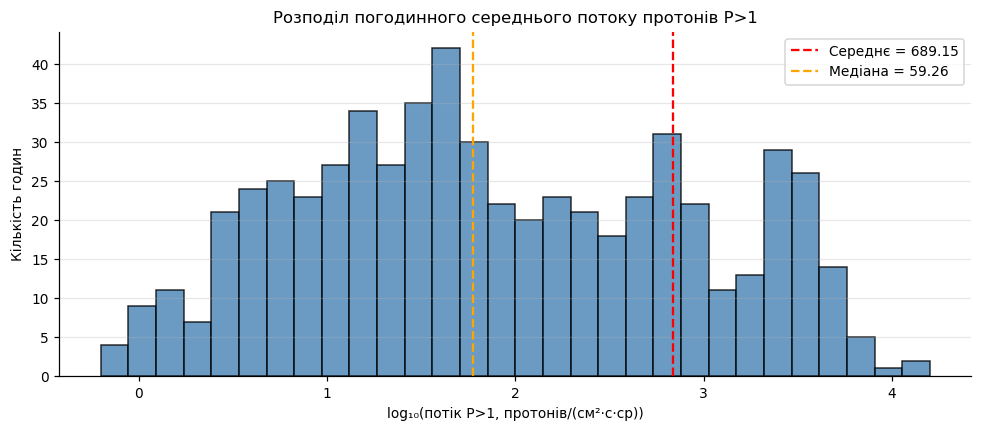

In [52]:
# ВАШ КОД
flow = M["proton_gt_1_MeV_mean"].dropna()

mean_flow = flow.mean()
median_flow = flow.median()

print(f"Середнє: {mean_flow:.2f}")
print(f"Медіана: {median_flow:.2f}")

log_flow = np.log10(flow[flow > 0])

plt.figure(figsize=(9, 4))

plt.hist(
    log_flow,
    bins=30,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    np.log10(mean_flow),
    color="red",
    linestyle="--",
    label=f"Середнє = {mean_flow:.2f}"
)

plt.axvline(
    np.log10(median_flow),
    color="orange",
    linestyle="--",
    label=f"Медіана = {median_flow:.2f}"
)

plt.title("Розподіл погодинного середнього потоку протонів P>1")
plt.xlabel("log₁₀(потік P>1, протонів/(см²·с·ср))")
plt.ylabel("Кількість годин")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок:**

Середнє і медіана сильно відрізняються через нерівномірний розподіл даних та наявність рідкісних, але дуже великих сплесків потоку протонів. Середнє значення чутливе до таких сплесків, тому воно збільшилося до 689,15. Медіана дорівнює 59,26 і показує типовіший рівень потоку: у половині годин значення було нижчим за неї, а в іншій половині - вищим. Отже, кілька екстремально великих значень значно підняли середнє, але майже не вплинули на медіану.
Розподіл потоку P>1 сильно зміщений у бік великих значень: протягом більшості годин потік був відносно невеликим, але окремі сильні сплески підвищили середнє до 689,15, тоді як медіана становить лише 59,26.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

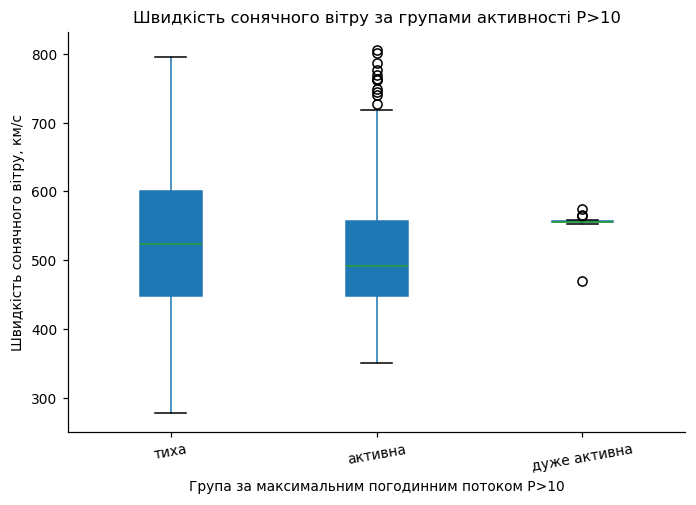

,count,median,mean,min,max
група,,,,,
тиха,403,524.0,511.3,277.0,795.0
активна,171,492.0,515.1,350.0,806.0
дуже активна,18,556.0,552.9,469.0,575.0


In [53]:
# ВАШ КОД

M.boxplot(
    column="proton_speed_km_s",
    by="група",
    grid=False,
    patch_artist=True
)

plt.suptitle("")

plt.title("Швидкість сонячного вітру за групами активності P>10")
plt.xlabel("Група за максимальним погодинним потоком P>10")
plt.ylabel("Швидкість сонячного вітру, км/с")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

speed_stats = (
    M.groupby("група", observed=False)["proton_speed_km_s"] #показувати всі визначені категорії, навіть якщо в якійсь із них зараз немає рядків.
     .agg(["count", "median", "mean", "min", "max"])
)

display(speed_stats.round(1))

**Висновок:**
Дуже активна група виглядає як вузька лінія, оскільки вона містить лише 18 годин, а основна частина значень швидкості зосереджена у дуже вузькому діапазоні приблизно 555–557 км/с.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції: -0.068


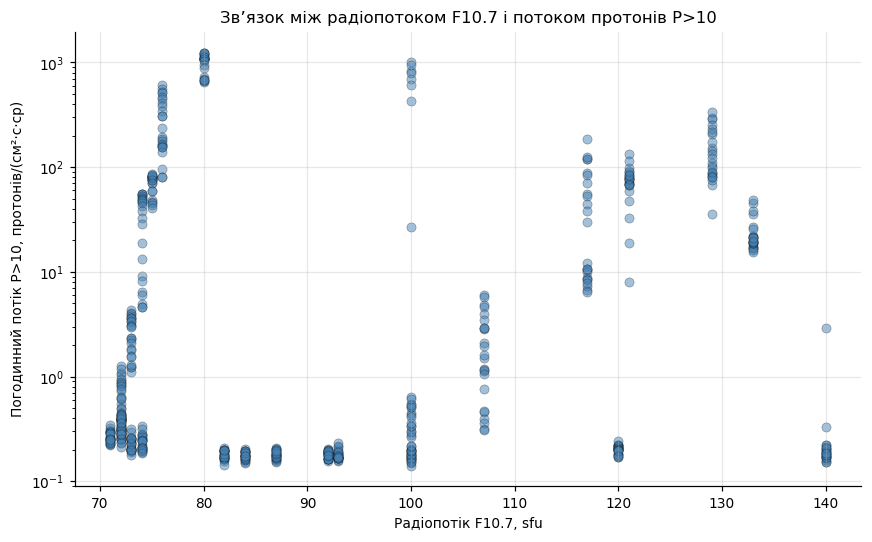

In [54]:
# ВАШ КОД
x_col = "radio_flux_10_7"
y_col = "proton_gt_10_MeV_mean"

pair = M[[x_col, y_col]].dropna()

correlation = pair[x_col].corr(pair[y_col])

print(f"Коефіцієнт кореляції: {correlation:.3f}")

plt.figure(figsize=(8, 5))

plt.scatter(
    pair[x_col],
    pair[y_col],
    alpha=0.5,
    color="steelblue",
    edgecolor="black",
    linewidth=0.3
)

plt.yscale("log")

plt.title("Зв’язок між радіопотоком F10.7 і потоком протонів P>10")
plt.xlabel("Радіопотік F10.7, sfu")
plt.ylabel("Погодинний потік P>10, протонів/(см²·с·ср)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок:** Помітного лінійного зв’язку між радіопотоком F10.7 і потоком протонів P>10 немає, оскільки коефіцієнт кореляції дорівнює приблизно −0,068 і є дуже близьким до нуля.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

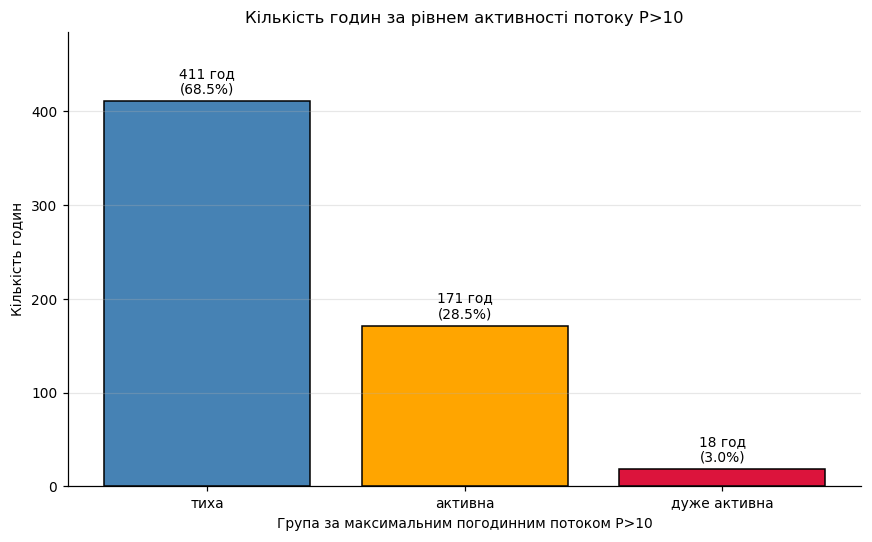

In [55]:
# ВАШ КОД

group_counts = M["група"].value_counts(sort=False)

group_percent = group_counts / group_counts.sum() * 100

plt.figure(figsize=(8, 5))

bars = plt.bar(
    group_counts.index.astype(str),
    group_counts.values,
    color=["steelblue", "orange", "crimson"],
    edgecolor="black"
)

for bar, count, percent in zip(
    bars,
    group_counts.values,
    group_percent.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count} год\n({percent:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.title("Кількість годин за рівнем активності потоку P>10")
plt.xlabel("Група за максимальним погодинним потоком P>10")
plt.ylabel("Кількість годин")

plt.ylim(0, group_counts.max() * 1.18)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Висновок:** Більшість досліджуваного часу припадає на тиху групу - 411 годин, або 68,5%, тоді як дуже активний рівень спостерігався лише протягом 18 годин, або 3% часу.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

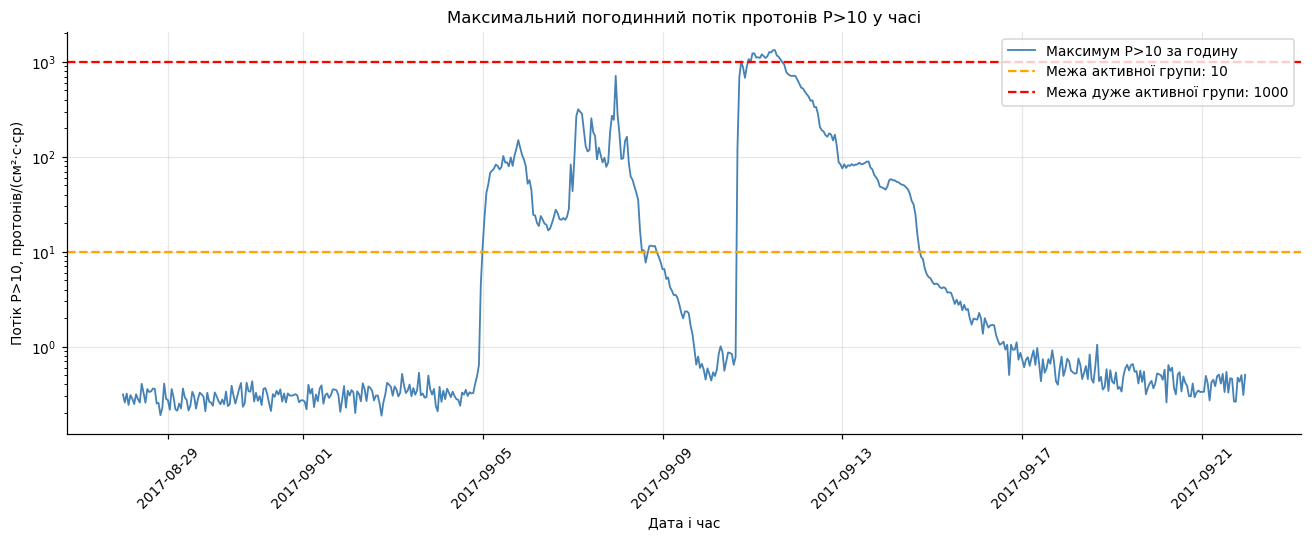

In [56]:
# ВАШ КОД
plt.figure(figsize=(12, 5))

plt.plot(
    M["ts"],
    M["proton_gt_10_MeV_max"],
    color="steelblue",
    linewidth=1.2,
    label="Максимум P>10 за годину"
)

plt.yscale("log")

plt.axhline(
    10,
    color="orange",
    linestyle="--",
    label="Межа активної групи: 10"
)

plt.axhline(
    1000,
    color="red",
    linestyle="--",
    label="Межа дуже активної групи: 1000"
)

plt.title("Максимальний погодинний потік протонів P>10 у часі")
plt.xlabel("Дата і час")
plt.ylabel("Потік P>10, протонів/(см²·с·ср)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Висновок:** Наприкінці серпня потік P>10 залишався низьким, у період із 5 до 14 вересня відбулися сильні сплески з найбільшим значенням 1330 протонів/(см²·с·ср) 11 вересня, після чого потік поступово повернувся до низького рівня.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

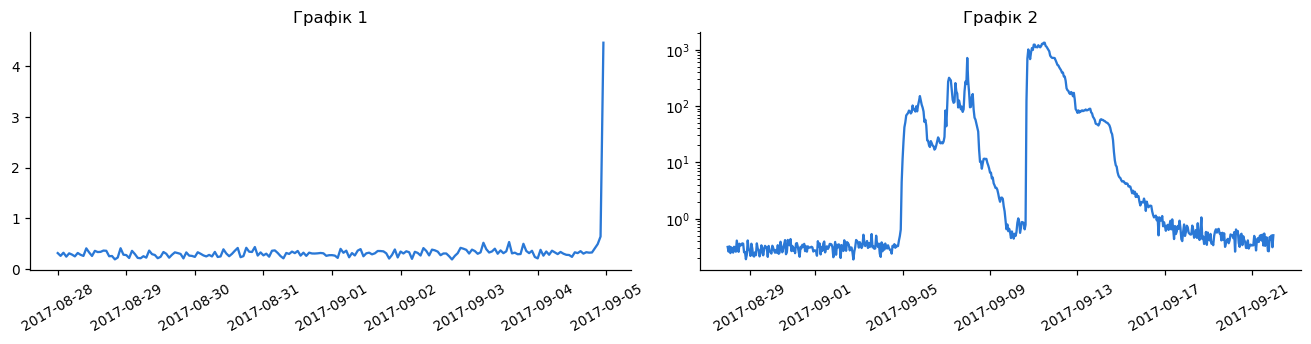

In [57]:
СТОВПЕЦЬ = "proton_gt_10_MeV_max"

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?

3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності -
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Людина, яка бачила лише перший графік, могла б зробити висновок, що наприкінці серпня та на початку вересня космічна погода була переважно спокійною, а 4 вересня почалося невелике зростання потоку протонів.
2. Висновок з другого графіка:Людина, яка бачила лише другий графік, зробила б висновок, що у вересні відбулися сильні сплески потоку P>10, особливо приблизно 10–12 вересня, після чого активність поступово знизилася.
3. Дві відмінності між ними:Графіки відрізняються двома параметрами:
      - перший показує тільки період від 28 серпня до 5 вересня, а другий - увесь період спостережень;
      - перший має звичайну лінійну шкалу Y, а другий - логарифмічну, яка дозволяє одночасно побачити дуже малі й дуже великі значення.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

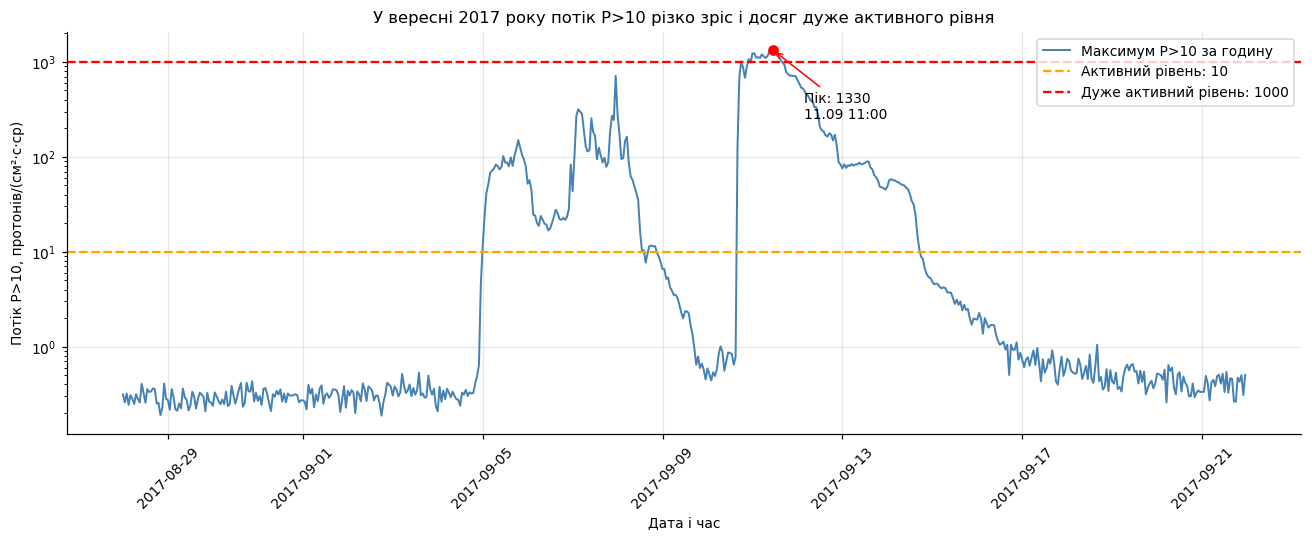

In [58]:
# ВАШ КОД

column = "proton_gt_10_MeV_max"

peak_time = M.loc[M[column].idxmax(), "ts"]
peak_value = M[column].max()

plt.figure(figsize=(12, 5))

plt.plot(
    M["ts"],
    M[column],
    color="steelblue",
    linewidth=1.3,
    label="Максимум P>10 за годину"
)

plt.yscale("log")

plt.axhline(
    10,
    color="orange",
    linestyle="--",
    label="Активний рівень: 10"
)

plt.axhline(
    1000,
    color="red",
    linestyle="--",
    label="Дуже активний рівень: 1000"
)

plt.scatter(
    peak_time,
    peak_value,
    color="red",
    zorder=3
)

plt.annotate(
    f"Пік: {peak_value:.0f}\n{peak_time:%d.%m %H:%M}",
    xy=(peak_time, peak_value),
    xytext=(20, -45),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "color": "red"
    }
)

plt.title(
    "У вересні 2017 року потік P>10 різко зріс і досяг дуже активного рівня"
)

plt.xlabel("Дата і час")
plt.ylabel("Потік P>10, протонів/(см²·с·ср)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Я показала весь період спостережень, щоб не приховувати ні спокійні години, ні сильні вересневі сплески. Логарифмічна шкала потрібна через дуже широкий діапазон значень - приблизно від 0,188 до 1330. Також я додала межі активної та дуже активної груп і позначила максимальне значення, тому з графіка видно як загальну зміну потоку, так і рівень серйозності сплесків.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Середній погодинний потік P>1 дорівнює 689,15, а медіана - лише 59,26, тобто середнє приблизно у 11,6 раза більше через рідкісні сильні сплески. Це видно на гістограмі в графіку 1.
**Спостереження 2:** Тиха активність P>10 спостерігалася протягом 411 годин, або 68,5% усього часу, тоді як дуже активна - лише протягом 18 годин, або 3%. Це видно на стовпчиковій діаграмі в графіку 4.
**Спостереження 3:** Між радіопотоком F10.7 і потоком протонів P>10 не виявлено помітного лінійного зв’язку, оскільки коефіцієнт кореляції дорівнює приблизно −0,068. Це видно на діаграмі розсіювання в графіку 3, де точки не утворюють чіткого висхідного або спадного напрямку.


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [59]:
# ВАШ КОД
flow = M["proton_gt_1_MeV_mean"].dropna()

flow_median = flow.median()
hours_above_median = (flow > flow_median).sum()
percent_above = hours_above_median / len(flow) * 100

print(f"Медіана потоку: {flow_median:.2f}")
print(f"Годин вище медіани: {hours_above_median}")
print(f"Частка часу: {percent_above:.1f}%")

Медіана потоку: 59.26
Годин вище медіани: 300
Частка часу: 50.0%


**Відповідь 7.2:** 

Медіанне значення погодинного потоку P>1 становить 59,26 протонів/(см²·с·ср). За весь період потік перевищував цю медіану протягом 300 із 600 годин, тобто 50% часу. Це очікувано, оскільки медіана ділить упорядковані значення приблизно на дві рівні частини.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [60]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = '''Я запускала код у своєму ноутбуці та перевіряла отримані таблиці й графіки.
Звірено розміри таблиць, діапазони дат, 8 некоректних значень у кожному
показнику таблиці C, середнє 689.15 і медіану 59.26 для P>1,
розподіл 411, 171 і 18 годин за групами та кореляцію -0.068.
Також виправлено рік 17 на 2017 і перевірено назви та одиниці вимірювання.'''

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [61]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Гуменюк Анастасія Олександрівна
інструменти:                                   ChatGPT
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Я запускала код у своєму ноутбуці та перевіряла отримані таблиці й графіки.
Звірено розміри таблиць, діапазони дат, 8 некоректних значень у кожному
показнику таблиці C, середнє 689.15 і медіану 59.26 для P>1,
розподіл 411, 171 і 18 годин за групами та кореляцію -0.068.
Т

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [62]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [63]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
